In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import stats

In [28]:
def add_noise(image, sigma_normalized=0.15):
    """Añade ruido gaussiano a la imagen normalizada."""
    noise = np.random.normal(0, sigma_normalized, image.shape)
    noisy_img = image + noise
    return np.clip(noisy_img, 0.0, 1.0).astype(np.float32)

def gibbs_joint_denoise_segment(noisy_img, K=3, burn_in=8, samplings=4, 
                                sigma=0.15, beta_y=0.1, beta_z=1.2):
    """
    Muestreo de Gibbs para Limpieza (Y) y Segmentación (Z) conjuntas.
    - Y usa Norma L-1 (Variación Total) para preservar bordes.
    - Z usa el Modelo de Potts para coherencia de regiones.
    """
    M, N = noisy_img.shape
    Y = np.copy(noisy_img)
    
    bins = np.linspace(0, 1, K + 1)
    
    # 2. Los centros mu_k serán el punto medio exacto de cada intervalo
    # Si K=4, mu_k será: [0.125, 0.375, 0.625, 0.875]
    mu_k = (bins[:-1] + bins[1:]) / 2
    
    # 3. Inicialización de Z (Segmentación)
    Z = np.clip(np.digitize(noisy_img, bins) - 1, 0, K - 1).astype(int)

    # Espacios de estados vectorizados
    levels_Y = np.linspace(0, 1, 100) # 100 niveles de intensidad para Y
    states_Y = levels_Y.reshape(-1, 1)
    states_Z = np.arange(K).reshape(-1, 1) # K clases para Z
    
    # ventana para vecinos
    dy = [-1, -1, -1,  0, 0,  1, 1, 1]
    dx = [-1,  0,  1, -1, 1, -1, 0, 1]
    
    samples_Y = []
    samples_Z = []
    
    total_iterations = burn_in + samplings
    
    print("Iniciando Muestreo de Gibbs (Limpieza y Segmentación)...")
    for it in range(total_iterations):
        fase = "Burn-in" if it < burn_in else "Sampling"
        print(f"Iteración {it + 1}/{total_iterations} ({fase})")
        
        for i in range(1, M - 1):
            for j in range(1, N - 1):
                x_ij = noisy_img[i, j]

                y_neighbors = np.array([Y[i+dy[k], j+dx[k]] for k in range(8)])
                z_neighbors = np.array([Z[i+dy[k], j+dx[k]] for k in range(8)])
                
                #ACTUALIZACIÓN DE LIMPIEZA (Y)
                u_obs_y = ((states_Y - x_ij)**2) / (2 * sigma**2)
                u_borde = beta_y * np.sum(np.abs(states_Y - y_neighbors), axis=1, keepdims=True)
                energy_y = (u_obs_y + u_borde).flatten()
                
                energy_y -= np.min(energy_y) # Estabilidad numérica
                probs_y = np.exp(-energy_y)
                probs_y /= np.sum(probs_y)
                Y[i, j] = levels_Y[np.random.choice(len(levels_Y), p=probs_y)]
                
                #ACTUALIZACIÓN DE SEGMENTACIÓN (Z)
                u_obs_z = ((mu_k[states_Z] - x_ij)**2) / (2 * sigma**2)
                u_clase = beta_z * np.sum(1 - (states_Z == z_neighbors), axis=1, keepdims=True)
                energy_z = (u_obs_z + u_clase).flatten()
                
                energy_z -= np.min(energy_z)
                probs_z = np.exp(-energy_z)
                probs_z /= np.sum(probs_z)
                Z[i, j] = np.random.choice(K, p=probs_z)
                
        # Guardar realizaciones solo durante la fase estacionaria
        if it >= burn_in:
            samples_Y.append(np.copy(Y))
            samples_Z.append(np.copy(Z))
            
    print("Construyendo reconstrucción final...")
    Y_final = np.mean(samples_Y, axis=0)
    # Segmentación: Voto mayoritario (Moda estadística)
    Z_mode = stats.mode(samples_Z, axis=0, keepdims=False)
    Z_final = Z_mode.mode
    
    return Y_final, Z_final


In [29]:
img_path = 'loros2.jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (100, 100))
img = img / 255.0 # Normalización

noisy_image = add_noise(img, sigma_normalized=0.05) 

# Ejecutar modelo conjunto
cleaned_img, segmented_img = gibbs_joint_denoise_segment(
    noisy_image, 
    K=3,           
    burn_in=8, 
    samplings=15,
    sigma=0.05,
    beta_y=4.0,    # Fuerza de preservación de bordes
    beta_z=3     # Fuerza de aglomeración del modelo de Potts
)

Iniciando Muestreo de Gibbs (Limpieza y Segmentación)...
Iteración 1/23 (Burn-in)
Iteración 2/23 (Burn-in)
Iteración 3/23 (Burn-in)
Iteración 4/23 (Burn-in)
Iteración 5/23 (Burn-in)
Iteración 6/23 (Burn-in)
Iteración 7/23 (Burn-in)
Iteración 8/23 (Burn-in)
Iteración 9/23 (Sampling)
Iteración 10/23 (Sampling)
Iteración 11/23 (Sampling)
Iteración 12/23 (Sampling)
Iteración 13/23 (Sampling)
Iteración 14/23 (Sampling)
Iteración 15/23 (Sampling)
Iteración 16/23 (Sampling)
Iteración 17/23 (Sampling)
Iteración 18/23 (Sampling)
Iteración 19/23 (Sampling)
Iteración 20/23 (Sampling)
Iteración 21/23 (Sampling)
Iteración 22/23 (Sampling)
Iteración 23/23 (Sampling)
Construyendo reconstrucción final...


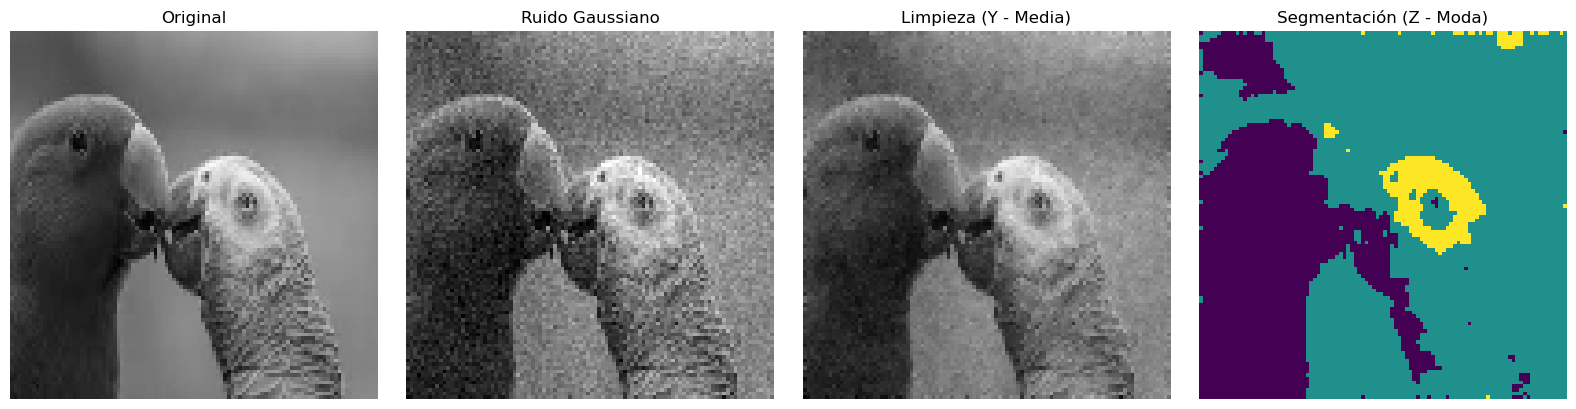

In [30]:
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.title('Original')
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Ruido Gaussiano')
plt.imshow(noisy_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Limpieza (Y - Media)')
plt.imshow(cleaned_img, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Segmentación (Z - Moda)')
plt.imshow(segmented_img, cmap='viridis') 
plt.axis('off')

plt.tight_layout()
plt.show()